In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("data/HateSpeechDatasetBalanced.csv")

In [3]:
df.head()

,Content,Label
0,denial of normal the con be asked to comment o...,1
1,just by being able to tweet this insufferable ...,1
2,that is retarded you too cute to be single tha...,1
3,thought of a real badass mongol style declarat...,1
4,afro american basho,1


In [4]:
import seaborn as sns

<Axes: xlabel='Label', ylabel='count'>

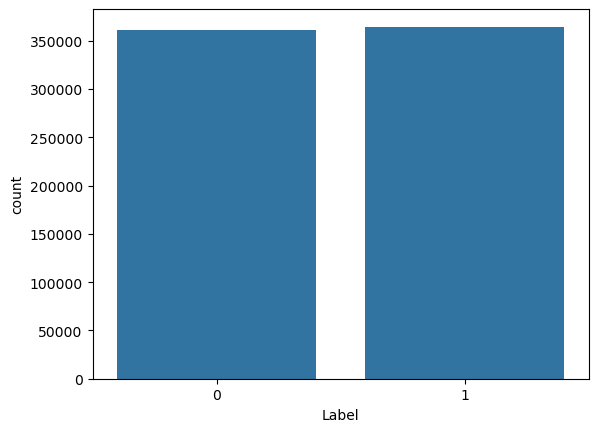

In [5]:
sns.countplot(x='Label', data=df)

In [6]:
#0 = No Hate
#1 = Hate

In [7]:
x = df['Content']
y = df['Label']

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
# Let's split the data into train and test
x_train,x_test,y_train,y_test = train_test_split(x,y, random_state = 42)

print(len(x_train),len(y_train))
print(len(x_test),len(y_test))

544589 544589
181530 181530


In [10]:
## Feature engineering

In [11]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [12]:
max_words = 50000
max_len = 300

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(x_train)

sequences = tokenizer.texts_to_sequences(x_train)
sequences_matrix = pad_sequences(sequences,maxlen=max_len)

In [13]:
sequences_matrix

array([[    0,     0,     0, ...,  3820,   542,  2416],
       [    0,     0,     0, ...,   499,   345, 30538],
       [    0,     0,     0, ...,  5045,   438,   110],
       ...,
       [    0,     0,     0, ...,     1, 22636,  5651],
       [    0,     0,     0, ...,   117,    16,  1345],
       [    0,     0,     0, ...,  1307,    14,  6468]], dtype=int32)

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Activation, Dense, Dropout, Input, Embedding, SpatialDropout1D
from tensorflow.keras.optimizers import RMSprop

In [15]:
# Creating model architecture.
model = Sequential()
model.add(Embedding(max_words,100,input_length=max_len))
model.add(SpatialDropout1D(0.2))
model.add(LSTM(100,dropout=0.2,recurrent_dropout=0.2))
model.add(Dense(1,activation='sigmoid'))
model.summary()

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(loss='binary_crossentropy',optimizer=RMSprop(),metrics=['accuracy'])

In [17]:
# starting model training
history = model.fit(sequences_matrix,y_train,batch_size=128,epochs = 1,validation_split=0.2)

3404/3404 ━━━━━━━━━━━━━━━━━━━━ 1865s 548ms/step - accuracy: 0.8086 - loss: 0.4168 - val_accuracy: 0.8277 - val_loss: 0.3908


In [18]:
test_sequences = tokenizer.texts_to_sequences(x_test)
test_sequences_matrix = pad_sequences(test_sequences,maxlen=max_len)

In [19]:
test_sequences_matrix

array([[    0,     0,     0, ...,   261,     4,    13],
       [    0,     0,     0, ...,   114,    38,    29],
       [    0,     0,     0, ...,  8342,    14, 14311],
       ...,
       [    0,     0,     0, ...,  3626,     3,    83],
       [    0,     0,     0, ...,     1,   181,  8330],
       [    0,     0,     0, ...,    16,     1,  3151]], dtype=int32)

In [20]:
# Model evaluation
accr = model.evaluate(test_sequences_matrix,y_test)

5673/5673 ━━━━━━━━━━━━━━━━━━━━ 255s 45ms/step - accuracy: 0.8309 - loss: 0.3887


In [21]:
lstm_prediction = model.predict(test_sequences_matrix)

5673/5673 ━━━━━━━━━━━━━━━━━━━━ 245s 43ms/step


In [22]:
res = []
for prediction in lstm_prediction:
    if prediction[0] < 0.5:
        res.append(0)
    else:
        res.append(1)

In [23]:
from sklearn.metrics import confusion_matrix

In [24]:
print(confusion_matrix(y_test,res))

[[77017 13074]
 [17616 73823]]


In [25]:
import pickle
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [26]:
# Let's save the model.
model.save("model.h5")

In [27]:
import keras
import re
import nltk
import string
from nltk.corpus import stopwords

In [28]:
# Let's apply stemming and stopwords on the data
stemmer = nltk.SnowballStemmer("english")
stopword = set(stopwords.words('english'))

In [29]:
load_model=keras.models.load_model("model.h5")
with open('tokenizer.pickle', 'rb') as handle:
    load_tokenizer = pickle.load(handle)

In [30]:
test = 'i love to watch this movie'

def clean_text(text):
    print(text)
    text = str(text).lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    print(text)
    text = [word for word in text.split(' ') if word not in stopword]
    text=" ".join(text)
    text = [stemmer.stem(word) for word in text.split(' ')]
    text=" ".join(text)
    return text

test=[clean_text(test)]
print(test)

seq = load_tokenizer.texts_to_sequences(test)
padded = pad_sequences(seq, maxlen=300)
print(seq)

pred = load_model.predict(padded)

print("pred", pred)
if pred<0.5:
    print("no hate")
else:
    print("hate and abusive")

i love to watch this movie
i love to watch this movie
['love watch movi']
[[124, 493]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
pred [[0.18793802]]
no hate
